<a href="https://colab.research.google.com/github/franciscoweitzman-cyber/aps_francisco_weitzman/blob/main/TS4/TS4_WEITZMAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Semanal N° 4
## Por: Francisco Weitzman
### UNSAM


##Introducción
En el siguiente trabajo vamos a simular la detección de una señal tomando 200 muestras del mismo experimento. Alrededor de una frecuencia $Ω_0$, con una distribución uniforme, vamos a modelar una variación con la que vamos a detectar nuestra frecencia de mayor peso, una frecuencia que va a ir entre $\pm2 Bins$. Además tendremos un ruido blanco de una distribución normal con un $σ$ vinculado a valores de SNR de {3dB,10dB}.

Luego, vamos a crear unos estimadores, analizar su uso, impacto, qué nos dice de nuestro análisis o qué información podemos extraer de ellos y cuánto podemos confiar en ellos. Para ello, vamos a explorar los conceptos de varianza y sesgo de nuestros estimadores, que son indicadores de qué tan consistentes o precisos y qué tan exactos son esos parámetros. Vamos a hacer uso de las ventanas (o windows) para ver cómo cambian estos estimadores y nuestros gráficos y por qué.

## Definiciones
Vamos a arrancar con algunas definiciones como nos lo proponen en la TS4:

In [22]:

from scipy.signal import windows
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#%% Definiciones
ps=1#W
a0=np.sqrt(2)
N=1000 # N es 2pi. Un Bin es una unidad de resolucion espectral df
nn=np.arange(0,N).reshape(N,1)
R=200
fs=1000 # La relacion que hay entre la frecuecia de sampleo:
df=fs/N # Que de 1 hace que mis bins caigan en multiplos de 1Hz
omega0=N/4 # Bin referido a pi/2 en mi rueda de frecuencias.
fr=np.random.uniform(-2,2,R).reshape(1,R)
omega1=(omega0+fr)*df

Ahora vamos a definir nuestra señal base, una matriz de N=1000 muestras temporales perfiladas en filas y R=200 experimentos ubicados en las columnas de la matriz. xs tiene dimensiones (1000,200). Luego definimos también nuestras ventanas en una estructura de python llamada "diccionario" (tipo de dato 'dict'):

In [23]:
#%% Señal y ventanas
snrs=[3,10]#dB
omega1=(omega0+fr)*df
frecReal=omega1.reshape(R)
xs=a0*np.sin(omega1*2*np.pi*nn/fs) # Hay que dividirlo por fs porque nn va a terminar siendo N. nn/fs va a cancelar las unidades de df que estan en omega1
ventanas={"Rectangular":np.ones((N,1)),
          "Flat-top":windows.flattop(N,sym=False).reshape(N,1),
          "Blackman-Harris":windows.blackmanharris(N,sym=False).reshape(N,1),
          "Hann":windows.hann(N,sym=False).reshape(N,1)}



---


Yendo ahora sí de cabeza con los estimadores, las transformadas y sus análisis, voy a presentar el código que usé para desarrollarlo. Creamos tres diccionarios que vamos a completar con dos loops integrados.


---


(Disclaimer) usé la IA (Claude) para que haga este proceso ordenado y fácil de escalar. Aprendí a usar este tipo de datos que veo ahora una gigante aplicación por su comodidad y versatilidad. Estos vinculan tipos de datos como strings, donde vamos a poner el nombre de nuestras cosas (por ejemplo nuestras ventanas) y luego vamos a asociarles a esos nombres nuestros datos (las ventanas). El código original está en el archivo TS4.py que es todo de mi creación. Esto sólo lo usé para que me lo extienda a un número arbitrario de SNR y de Ventanas. Me sirvió para elevar mi conocimiento de python y lograr un código más robusto y sencillo, escalable y versátil preservando la estética y minimalismo de mi código. (Fin de la cita)


---


El código se lee así:

Por cada SNR en mi vector snrs, creame una matriz de señales "xx" con su potencia de ruido y esa variación en la frecuencia dominante. Luego, por cada ventana, creame un diccionario de matrices $XX*W(ω)$ que tenga la información de las transformadas normalizadas (Por un factor $\frac{1}{N}$) de la multiplicación de la matriz de señales por las distintas ventanas. También, por cada una de esas transformadas, calculame los estimadores de amplitud y frecuencia vinculados a cada SNR y cada Ventana.

In [24]:
#%% Estimadores
estAbs={}
estFrec={}
trW={}

for snr in snrs:
    pr=ps/(10**(snr/10))
    na=np.random.normal(0,np.sqrt(pr),(N,R))
    xx=xs+na
    for nombre,w in ventanas.items(): # axis = 0 toma un valor de columna y recorre las filas. axis=1 recorre las columnas de una fila
        tr_w=(1/N)*np.fft.fft(xx*w, axis=0) #tr_w es la matriz transformada en dft con sus ventanas
        trW[snr,nombre] = tr_w
        estAbs[snr,nombre]=2*np.abs(tr_w[N//4,:]) #/np.mean(w)  Así podemos compensar la ganancia de la ventana
        estFrec[snr,nombre]=np.argmax(np.abs(tr_w[:N//2,:]), axis=0)*df

Veamos cómo definí mis estimadores:

estAbs tiene un factor 2 que proviene de la naturaleza simétrica de nuestra DFT que replica las amplitudes **complejas** de 0 a R centrados en nuestro $Ω_0$ que es el Bin 250 y recorre los 200 experimentos ([N//4,:]) y se obtiene con el np.abs() que calcula el módulo de nuestra amplitud compleja. Este estimador nos indica la amplitud que cada experimento detectó en Fourier en la frecuencia a la que nosotros queremos detectar señal. Luego haremos histogramas para cada ventana y veremos cuál predice con mayor exactitud y precisión los valores de nuestra señal buscada.

Por otro lado, estFrc mide la frecuencia a la cual hubo un pico máximo de amplitud en cada experimento. Nuevamente tendremos un vector de 200 valores. Luego calcularemos sus valores esperados y su varianza. Ahora volvemos a las señales:

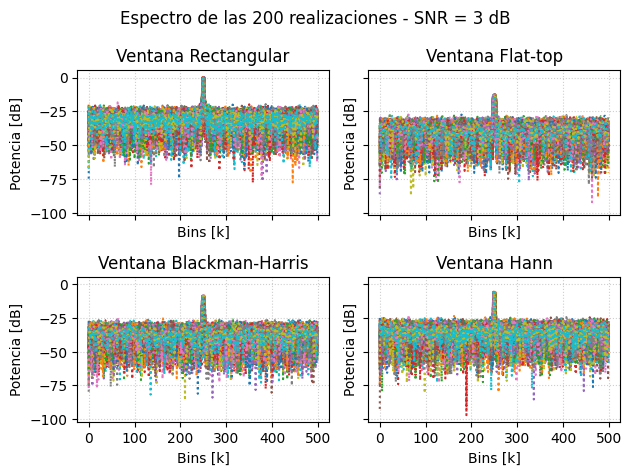

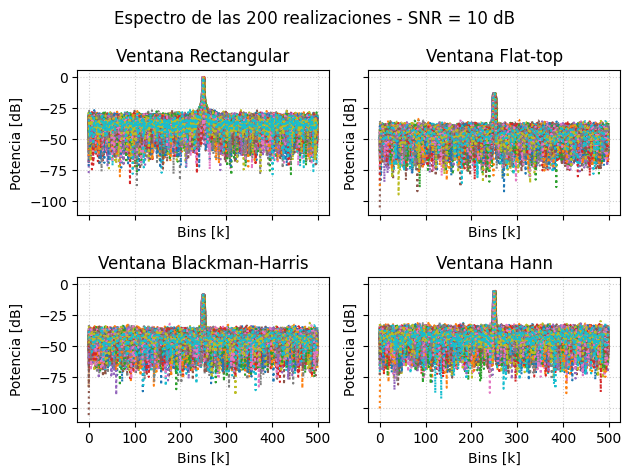

In [25]:
#%% Espectro en dB por ventana
k=nn[:N//2]

for snr in snrs:
    fig,ejes=plt.subplots(2,2,sharex=True,sharey=True)
    for eje,nombre in zip(ejes.flatten(),ventanas):
        modulo_tr_db=20*np.log10(2*np.abs(trW[snr,nombre][:N//2,:])/a0)
        eje.plot(k, modulo_tr_db, ":")
        eje.set_title(f"Ventana {nombre}")
        eje.set_xlabel("Bins [k]")
        eje.set_ylabel("Potencia [dB]")
        eje.grid(True, linestyle=':', alpha=0.6)
    fig.suptitle(f"Espectro de las {R} realizaciones - SNR = {snr} dB")
    fig.tight_layout()
    plt.show()

 Para verlo mejor le hice zoom. Lo primero que podemos apreciar es que las frecuecias centrales no se ven atenuadas en la rectangular, pero en las demás sí hay una gran baja en las potencias de las frecuencias de los bins [248;252]. Sabemos que los bins que disponemos para describir nuestra señal son los enteros ya que nuestra resolución espectral es de 1Hz/Bin. Toda "fr" que caiga entre dos valores enteros, va a tener que ser descripta por las frecuencias existentes, que si bien son ortogonales, el producto interno en las N muestras temporales no es $=0$ entonces ocurre el llamado "Derrame espectral". A este derrame le podemos suavizar o reducir su ruido inherente con las distintas ventanas que le dan mayo peso a las frecuencias de mayor peso y reducen la de los efectos del derrame. La forma que operan es, al ser una multiplicación en el tiempo, es una convolución en el dominio de las frecuencias. Sabemos que la convolución tiene la capacidad de homogeneizar o promediar los efectos secundarios y le dan más valor a aquellos que coinciden en frecuencia entre las dos funciones en cuestión.

 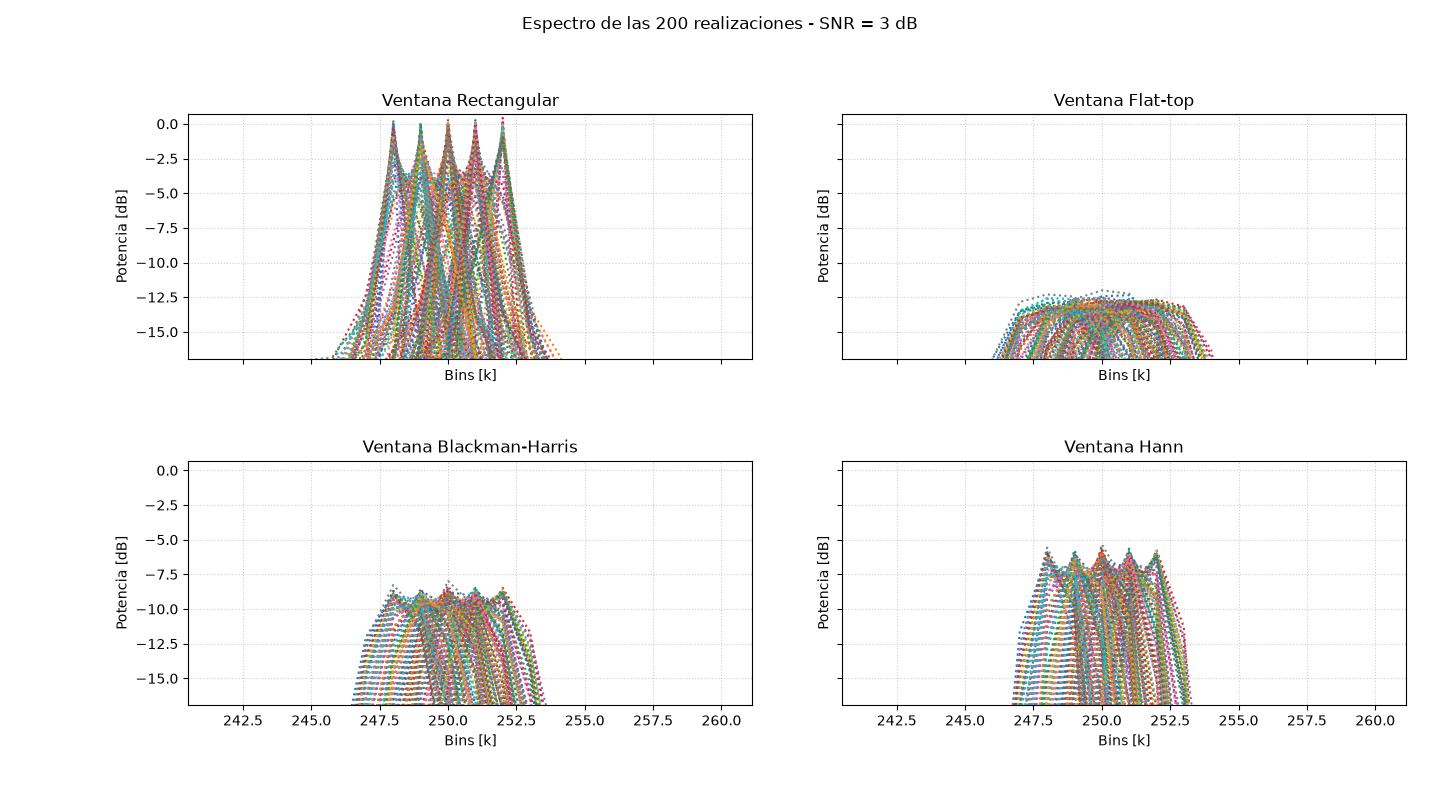

Otra cosa que vemos es el ruido en las afueras de los picos de amplitudes:
vemos que mientras que la rectangular se queda en -30dB y en las cercanías es de -20db, en las demás caen más abruptamente aunque un par de bins después a -40dB

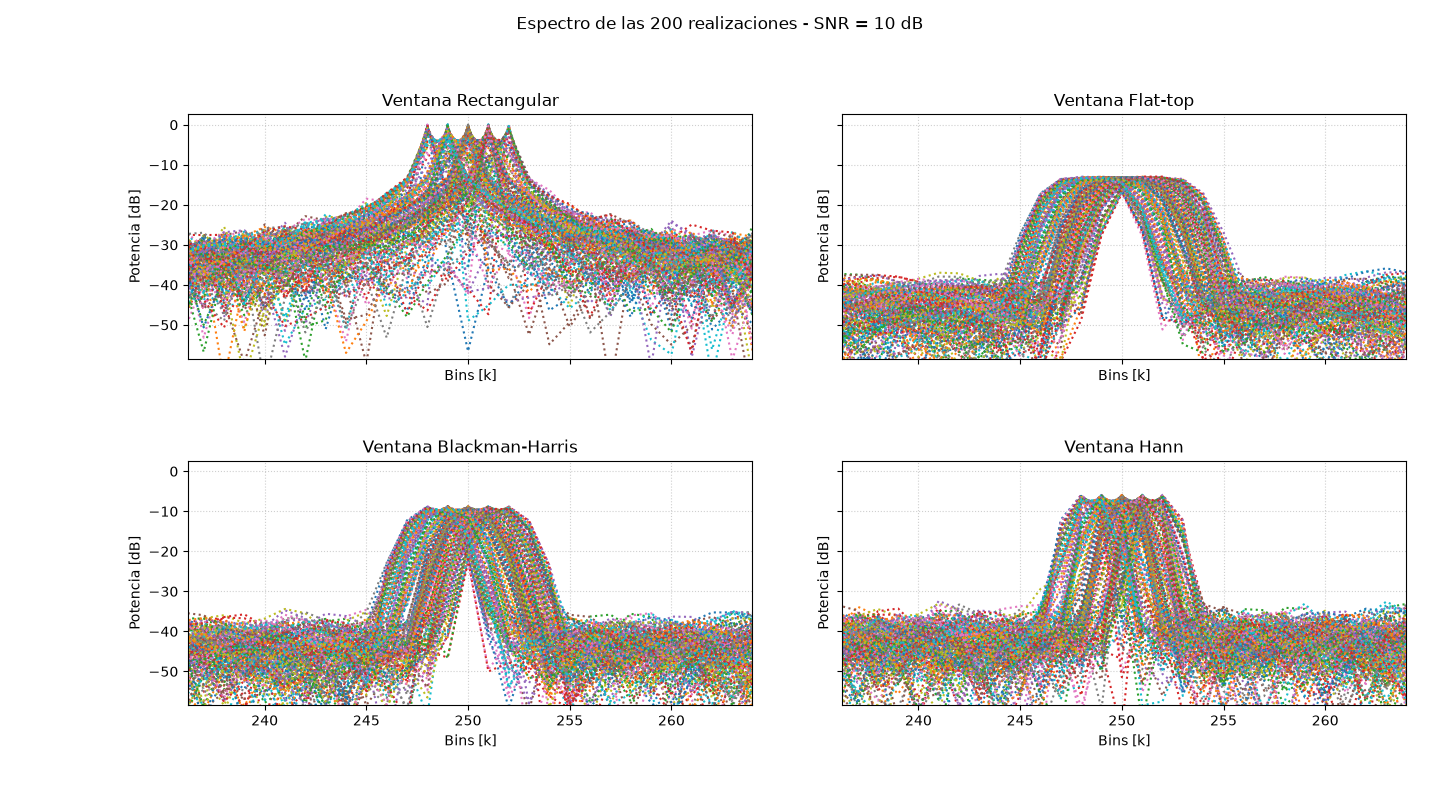

Ahora pasemos a los Histogramas:

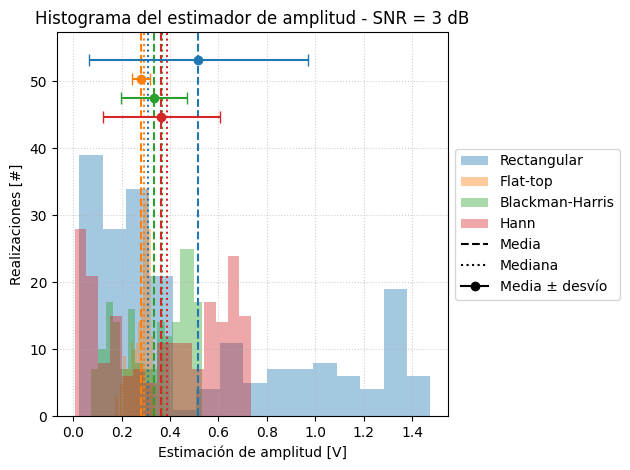

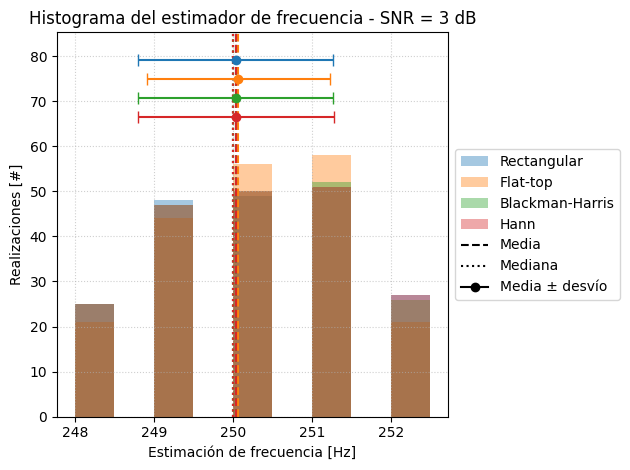

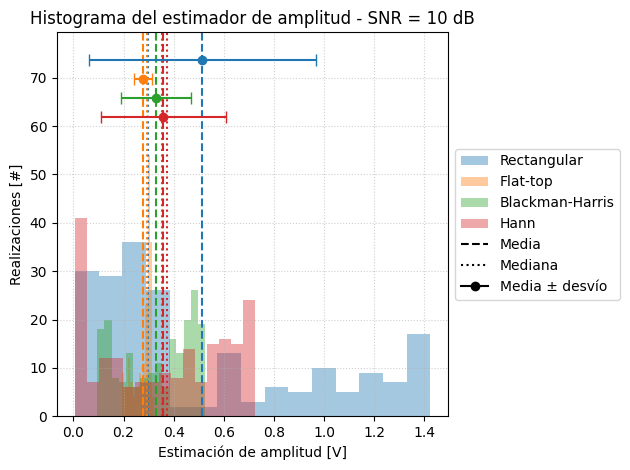

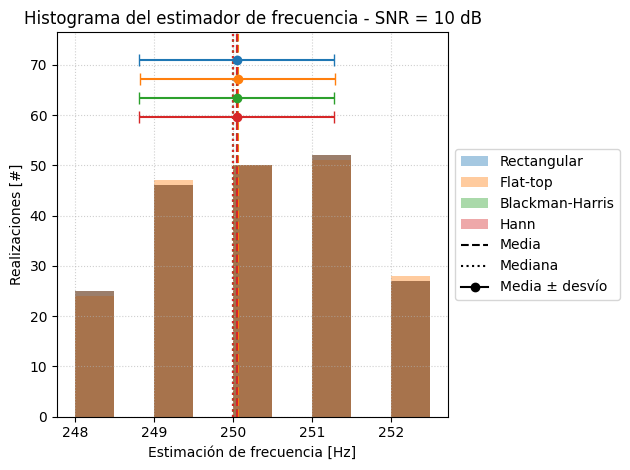

In [26]:
#%% Histogramas
for snr in snrs:
    for est,unidad,titulo,bins in ((estAbs,"V","amplitud",15),(estFrec,"Hz","frecuencia",np.arange(248,253,df/2))):
        fig=plt.figure()
        for i,nombre in enumerate(ventanas):
            datos=est[snr,nombre]
            plt.hist(datos, bins=bins, alpha=0.4, color="C"+str(i), label=nombre)
            plt.axvline(np.mean(datos), color="C"+str(i), linestyle="--")
            plt.axvline(np.median(datos), color="C"+str(i), linestyle=":")
        ymax=plt.ylim()[1]
        plt.ylim(0, 1.4*ymax)
        for i,nombre in enumerate(ventanas):
            datos=est[snr,nombre]
            plt.errorbar(np.mean(datos), ymax*(1.3-0.07*i), xerr=np.std(datos), fmt="o", color="C"+str(i), capsize=4)
        plt.plot([],[],"k--",label="Media")
        plt.plot([],[],"k:",label="Mediana")
        plt.plot([],[],"k-o",label="Media ± desvío")
        plt.title(f"Histograma del estimador de {titulo} - SNR = {snr} dB")
        plt.xlabel(f"Estimación de {titulo} [{unidad}]")
        plt.ylabel("Realizaciones [#]")
        plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

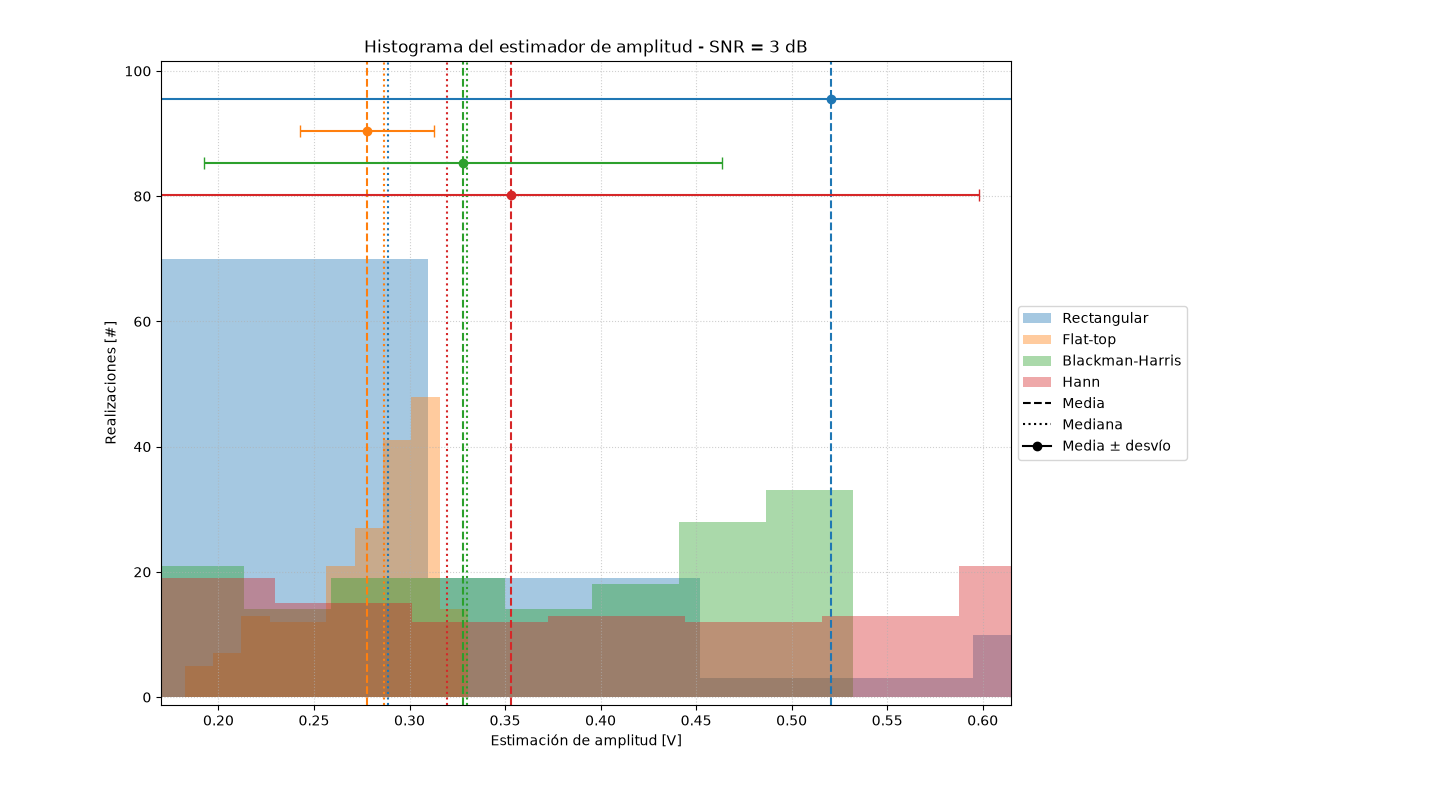

De los estimadores de Frecuencia, podemos decir gráficamente que para cualquier ventana es un buen estimador. La desviación estándar y la media son prácticamente iguales en todas.

Ahora bien, en los estimadores de Amplitud notamos un sesgo y una varianza considerables. Vemos que al reducir la varianza, aumentamos el sesgo. En cuanto al valor esperado, midiéndolo con la media, notamos que a veces hay una gran diferencia con respecto a la mediana, como es el caso de la rectangular. con una mediana en 0.52 bins y una media en 0.28 bins. Esto depende de qué necesitemos calcular: si un valor que tenga las mismas muestras de un lado que del otro (mediana) o un valor que sea el promedio de todos los valores existentes (media). El problema de la media son las anomalías estadísticas, y  la mediana no se lleva bien con grandes valores de desviación estándar. Como podemos apreciar, la rectangular es la que menos sesgo tiene (es la que más cerca está de los 1,4V de amplitud pico por lejos), pero su desviación estándar es brutal. Eso se debe a la Sinc que genera su convolución en el dominio de Fourier. Por otro lado, la de menor varianza vendría siendo la flat top, aunque su sesgo es tambien gigante. Pero esto es mejor, ya que si siempre le "pifiamos" pero somos regulares con "qué tan lejos le pifiamos", significa que podemos calibrarlo. Si en promedio le pegamos alrededor de un valor pero con una dispersión gigante, no puedo asegurar que las probabilidades de pegarle en el centro sean altas.

Se ve que hay una forma de calibrarlo. Si dividimos el vector de estimadores por la media, logramos hacer que la Flattop sea la de menor varianza y sesgo de todas, al menos cuanto mayor sea el SNR (hay que bajar el ruido en el tiempo entonces). Esto es debido a que "llevamos a 0" los dB de la frecuencia central, algo que nuestra propia ventana se había encargado de reducir como vimos en los primeros gráficos.

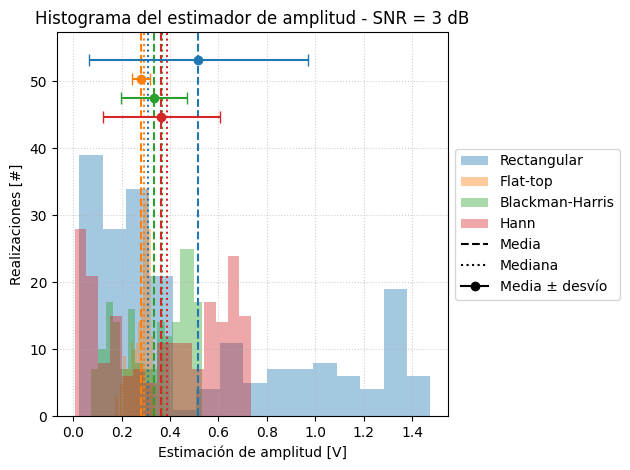

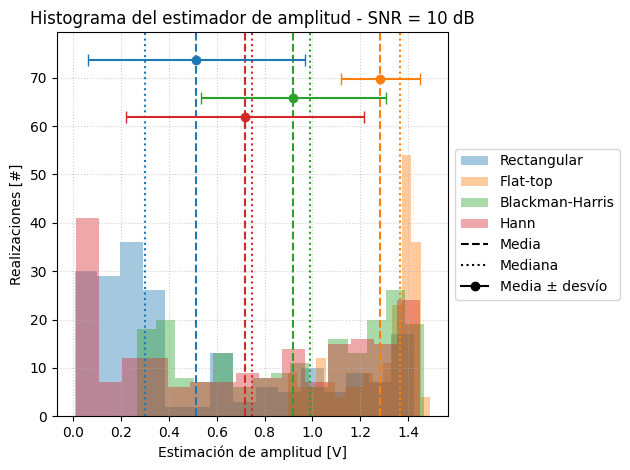

In [27]:
for nombre,w in ventanas.items(): # axis = 0 toma un valor de columna y recorre las filas. axis=1 recorre las columnas de una fila
        tr_w=(1/N)*np.fft.fft(xx*w, axis=0) #tr_w es la matriz transformada en dft con sus ventanas
        trW[snr,nombre] = tr_w
        estAbs[snr,nombre]=2*np.abs(tr_w[N//4,:]) /np.mean(w) # Así podemos compensar la ganancia de la ventana
        estFrec[snr,nombre]=np.argmax(np.abs(tr_w[:N//2,:]), axis=0)*df
#%% Histogramas
for snr in snrs:
    for est,unidad,titulo,bins in [(estAbs,"V","amplitud",15)]:
        fig=plt.figure()
        for i,nombre in enumerate(ventanas):
            datos=est[snr,nombre]
            plt.hist(datos, bins=bins, alpha=0.4, color="C"+str(i), label=nombre)
            plt.axvline(np.mean(datos), color="C"+str(i), linestyle="--")
            plt.axvline(np.median(datos), color="C"+str(i), linestyle=":")
        ymax=plt.ylim()[1]
        plt.ylim(0, 1.4*ymax)
        for i,nombre in enumerate(ventanas):
            datos=est[snr,nombre]
            plt.errorbar(np.mean(datos), ymax*(1.3-0.07*i), xerr=np.std(datos), fmt="o", color="C"+str(i), capsize=4)
        plt.plot([],[],"k--",label="Media")
        plt.plot([],[],"k:",label="Mediana")
        plt.plot([],[],"k-o",label="Media ± desvío")
        plt.title(f"Histograma del estimador de {titulo} - SNR = {snr} dB")
        plt.xlabel(f"Estimación de {titulo} [{unidad}]")
        plt.ylabel("Realizaciones [#]")
        plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

In [28]:
for nombre,w in ventanas.items(): # axis = 0 toma un valor de columna y recorre las filas. axis=1 recorre las columnas de una fila
        tr_w=(1/N)*np.fft.fft(xx*w, axis=0) #tr_w es la matriz transformada en dft con sus ventanas
        trW[snr,nombre] = tr_w
        estAbs[snr,nombre]=2*np.abs(tr_w[N//4,:]) #/np.mean(w)  Así podemos compensar la ganancia de la ventana
        estFrec[snr,nombre]=np.argmax(np.abs(tr_w[:N//2,:]), axis=0)*df

Para la tabla de valores tambien me ayudé de la IA ya que no sabía cómo armarla, aunque nuevamente los estimadores ya estaban calculados en el diccionario que surgió de la lógica que armé personalmente en el archivo TS4.py. De todos modos, de ahora en más tendré esta TS a mano para futuras tablas que necesitemos presentar.

In [29]:
#%% Tablas de sesgo y varianza
for snr in snrs:
    tablaAbs=pd.DataFrame({"s_a":[np.mean(estAbs[snr,n])-a0 for n in ventanas],
                           "v_a":[np.var(estAbs[snr,n]) for n in ventanas]}, index=list(ventanas))
    tablaFrec=pd.DataFrame({"s_f":[np.mean(estFrec[snr,n]-frecReal) for n in ventanas],
                            "v_f":[np.var(estFrec[snr,n]-frecReal) for n in ventanas]}, index=list(ventanas))
    print(f"SNR = {snr} dB")
    print(tablaAbs)
    print(tablaFrec)

SNR = 3 dB
                      s_a       v_a
Rectangular     -0.897399  0.204393
Flat-top        -1.134877  0.001308
Blackman-Harris -1.080837  0.018799
Hann            -1.049764  0.059286
                      s_f       v_f
Rectangular     -0.040332  0.081617
Flat-top        -0.005332  0.217728
Blackman-Harris -0.040332  0.082005
Hann            -0.035332  0.081892
SNR = 10 dB
                      s_a       v_a
Rectangular     -0.899246  0.204992
Flat-top        -1.137394  0.001267
Blackman-Harris -1.084102  0.019204
Hann            -1.055092  0.061432
                      s_f       v_f
Rectangular     -0.025332  0.082652
Flat-top        -0.015332  0.121960
Blackman-Harris -0.025332  0.082600
Hann            -0.025332  0.082600


Nuevamente se comprueba lo que vimos gráficamente. Sería interesante evaluar los valores esperados de los estimadores si los normalizamos con la media:

In [30]:
for nombre,w in ventanas.items(): # axis = 0 toma un valor de columna y recorre las filas. axis=1 recorre las columnas de una fila
        tr_w=(1/N)*np.fft.fft(xx*w, axis=0) #tr_w es la matriz transformada en dft con sus ventanas
        trW[snr,nombre] = tr_w
        estAbs[snr,nombre]=2*np.abs(tr_w[N//4,:]) /np.mean(w) # Así podemos compensar la ganancia de la ventana
        estFrec[snr,nombre]=np.argmax(np.abs(tr_w[:N//2,:]), axis=0)*df

#%% Tablas de sesgo y varianza
for snr in snrs:
    tablaAbs=pd.DataFrame({"s_a":[np.mean(estAbs[snr,n])-a0 for n in ventanas],
                           "v_a":[np.var(estAbs[snr,n]) for n in ventanas]}, index=list(ventanas))
    tablaFrec=pd.DataFrame({"s_f":[np.mean(estFrec[snr,n]-frecReal) for n in ventanas],
                            "v_f":[np.var(estFrec[snr,n]-frecReal) for n in ventanas]}, index=list(ventanas))
    print(f"SNR = {snr} dB")
    print(tablaAbs)
    print(tablaFrec)

SNR = 3 dB
                      s_a       v_a
Rectangular     -0.897399  0.204393
Flat-top        -1.134877  0.001308
Blackman-Harris -1.080837  0.018799
Hann            -1.049764  0.059286
                      s_f       v_f
Rectangular     -0.040332  0.081617
Flat-top        -0.005332  0.217728
Blackman-Harris -0.040332  0.082005
Hann            -0.035332  0.081892
SNR = 10 dB
                      s_a       v_a
Rectangular     -0.899246  0.204992
Flat-top        -0.130136  0.027260
Blackman-Harris -0.494041  0.149215
Hann            -0.695971  0.245726
                      s_f       v_f
Rectangular     -0.025332  0.082652
Flat-top        -0.015332  0.121960
Blackman-Harris -0.025332  0.082600
Hann            -0.025332  0.082600


Y vemos al menos que el sesgo de el estimador de amplitud es de un orden de magnitud menor que sin la corrección en el SNR=10dB

##Conclusiones
En este trabajo vimos los efectos de usar ventaneo, analizamos cómo estas técnicas combaten el derrame espectral y qué efectos secundarios tienen y cómo se pueden aminorar esos efectos negativos. También incorporamos el concepto de estimador, su sesgo y su varianza.

En cuanto a mi, aprendí aún más herramientas de Python como el tipo de dato dict, un tipo de dato muy util y versátil, y la librería Panda que me sirvió para exponer los valores de mis diccionarios automáticamente en tablas. Comprendí que ventanear en el tiempo es equivalente a convolucionar en el mundo de las frecuencias, aprendí a usar mejor el tema de las matrices y vectores en python, también muy útil.